# Bias–alignment dynamics and U-shaped population error

## Experimental question

This notebook investigates the interaction between normalized bias, normalized alignment, and population error in Gaussian-mixture classification. The analysis compares balanced and imbalanced class priors under three update conventions: self-training with labelled-only bias updates, self-training with fully coupled bias updates, and supervised learning without pseudo-labelled updates.

The principal quantities are the normalized bias $\breve b^t=b^t/\tau^t$, normalized alignment $\breve m^t=m^t/\tau^t$, and population error $\mathscr E^t$. For a fixed normalized alignment, the conditionally optimal bias is

$$
\breve b^\star(\breve m)=\frac{\sigma^2}{2\breve m}\log\!\left(\frac{p}{1-p}\right),
$$

and the globally optimal linear-classifier bias is $\breve b^\star=\breve b^\star(s_\mu)$.

In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Imports and visual conventions

In [25]:
from pathlib import Path
import sys

import numpy as np
import torch
from matplotlib import pyplot as plt
from scipy.special import logit

torch.set_default_dtype(torch.float64)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.experiment_helpers import (
    make_algorithm_config,
    plot_error_diagnostics,
    run_experiment,
)

In [26]:
FIGSIZE = (6.0, 4.0)
COLORS = {
    "bias": "#1f77b4",
    "conditional_optimum": "#ff7f0e",
    "global_optimum": "#d62728",
    "error_checkpoint": "#d62728",
    "alignment_checkpoint": "#9467bd",
    "crossing_checkpoint": "#222222",
}

plt.rcParams.update({
    "figure.figsize": FIGSIZE,
    "axes.grid": True,
    "grid.alpha": 0.30,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": False,
    "lines.linewidth": 2.0,
})

## Model and optimization settings

The six experiments cross two class priors, $p\in\{0.2,0.5\}$, with three update conventions. All other data-generation parameters and random seeds are held fixed.

In [27]:
SEED = 42
BAR_DELTA = 8.0
IMBALANCED_PRIOR = 0.2
BALANCED_PRIOR = 0.5
SIGMA = 1.0
S_MU = 1.0
RHO = 0.01
T = 1_000
D = 1_000
N_TEST = 0
K_W = 7_500
K_G = 10_000

LAMBDA = 0.1
KAPPA = logit(0.8)
INCLUDE_BIAS = True
INITIAL_BIAS = 0.0
RUN_FINITE = True
RUN_STATE_EVOLUTION = False

LABELLED_BIAS_ETA = 1.0
FULL_BIAS_ETA = 0.1
SUPERVISED_ETA = 1.0
SELF_TRAINING_PI = 2.0
SUPERVISED_PI = 0.0
LABELLED_ONLY_BIAS_WEIGHT = 0.0
FULL_BIAS_WEIGHT = None

## Diagnostic definitions

For every trajectory, the population error is decomposed as

$$
\mathscr E^t
=\mathscr E_{\mathrm{lin}}^\star
+\mathscr D_{\mathrm{align}}^t
+\mathscr D_{\mathrm{bias}}^t.
$$

The alignment regret $\mathscr D_{\mathrm{align}}^t$ compares the conditionally optimized error at $\breve m^t$ with the optimal linear error at $s_\mu$. The bias regret $\mathscr D_{\mathrm{bias}}^t$ is the additional error from using the learned bias rather than $\breve b^\star(\breve m^t)$.

The bias–alignment plots mark

$$
t_{\mathrm{err}}=\operatorname*{argmin}_{0\leq t\leq T}\mathscr E^t,\qquad
t_{\mathrm{align}}=\operatorname*{argmax}_{0\leq t\leq T}\breve m^t,\qquad
t_{\mathrm{cross}}=\operatorname*{argmin}_{0\leq t\leq T}
\left|\breve b^t-\breve b^\star(\breve m^t)\right|.
$$

## Reusable experiment and plotting functions

These notebook-local functions apply the same construction, validation, and plotting conventions to all six experiments. They orchestrate existing repository functions without modifying either learning recursion.

In [28]:
def run_bias_experiment(
    *,
    name,
    label_prior,
    eta,
    pseudo_label_param,
    bias_pseudo_label_param,
    include_bias=INCLUDE_BIAS,
    initial_bias=INITIAL_BIAS,
    kappa_pos=None,
    kappa_neg=None,
):
    """Run one finite-GD experiment with the shared data configuration."""

    algorithm_config = make_algorithm_config(
        T=T,
        eta=eta,
        penalty=LAMBDA,
        pi=pseudo_label_param,
        kappa=KAPPA,
        kappa_neg=kappa_neg,
        kappa_pos=kappa_pos,
        include_bias=include_bias,
        initial_bias=initial_bias,
        bias_pseudo_label_param=bias_pseudo_label_param,
    )
    assert algorithm_config.is_canonical_fixed_pi

    experiment = run_experiment(
        name=name,
        d=D,
        delta=BAR_DELTA,
        n_test=N_TEST,
        label_prior=label_prior,
        rho=RHO,
        sigma=SIGMA,
        signal_std=S_MU,
        algo_cfg=algorithm_config,
        seed=SEED,
        K_w=K_W,
        K_g=K_G,
        run_finite=RUN_FINITE,
        run_state_evolution=RUN_STATE_EVOLUTION,
        metadata={"oracle_calibration_diagnostic": True},
    )

    environment = experiment.environment
    print(
        f"{name}: p={label_prior:.1f}, n={environment.n}, d={environment.d}, "
        f"labelled={environment.N}, unlabelled={environment.M}, "
        f"delta_finite={environment.delta:.3f}, "
        f"s_mu={experiment.signal_scale:.4f}"
    )
    return experiment

In [29]:
def plot_experiment_error_decomposition(experiment, *, title):
    """Validate and plot the stored finite-trajectory error decomposition."""

    diagnostics = experiment.error_diagnostics["finite"]
    n_iterations = experiment.algo_cfg.n_iterations
    level_keys = (
        "normalized_alignment",
        "normalized_bias",
        "optimal_normalized_bias",
        "optimal_linear_error",
        "alignment_regret",
        "bias_regret",
        "error_reconstructed",
    )
    increment_keys = (
        "error_increment",
        "alignment_regret_increment",
        "bias_regret_increment",
    )
    assert all(
        np.asarray(diagnostics[key]).shape == (n_iterations + 1,)
        for key in level_keys
    )
    assert all(
        np.asarray(diagnostics[key]).shape == (n_iterations,)
        for key in increment_keys
    )

    regret_increment_sum = (
        np.asarray(diagnostics["alignment_regret_increment"])
        + np.asarray(diagnostics["bias_regret_increment"])
    )
    error_increment = np.asarray(diagnostics["error_increment"])
    finite_identity = np.isfinite(error_increment) & np.isfinite(regret_increment_sum)
    np.testing.assert_allclose(
        error_increment[finite_identity],
        regret_increment_sum[finite_identity],
        atol=1e-12,
    )

    fig, axes = plot_error_diagnostics(diagnostics, title=title, show=False)
    plt.show()
    return diagnostics, fig, axes

In [30]:
def plot_bias_alignment_checkpoints(experiment, *, title, ylim=None):
    """Plot normalized-bias calibration and report characteristic iterations."""

    diagnostics = experiment.error_diagnostics["finite"]
    normalized_bias = np.asarray(diagnostics["normalized_bias"], dtype=float)
    normalized_alignment = np.asarray(
        diagnostics["normalized_alignment"], dtype=float
    )
    conditional_optimal_bias = np.asarray(
        diagnostics["optimal_normalized_bias"], dtype=float
    )
    population_error = np.asarray(diagnostics["error_reconstructed"], dtype=float)
    assert (
        normalized_bias.shape
        == normalized_alignment.shape
        == conditional_optimal_bias.shape
        == population_error.shape
    )

    p = experiment.data_cfg.label_prior
    sigma = experiment.data_cfg.scale
    global_optimal_bias = (
        sigma**2 / (2.0 * experiment.signal_scale) * logit(p)
    )
    t_err = int(np.nanargmin(population_error))
    t_align = int(np.nanargmax(normalized_alignment))

    signed_bias_gap = normalized_bias - conditional_optimal_bias
    finite_gap = np.isfinite(signed_bias_gap)
    if not np.any(finite_gap):
        raise RuntimeError("conditional bias is nonfinite at every iteration")
    absolute_bias_gap = np.where(finite_gap, np.abs(signed_bias_gap), np.inf)
    t_cross = int(np.argmin(absolute_bias_gap))

    finite_pairs = finite_gap[:-1] & finite_gap[1:]
    sign_change_intervals = np.flatnonzero(
        finite_pairs & (signed_bias_gap[:-1] * signed_bias_gap[1:] < 0.0)
    )
    has_sign_change = sign_change_intervals.size > 0

    fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)
    iterations = np.arange(normalized_bias.size)
    ax.plot(iterations, normalized_bias, color=COLORS["bias"], label=r"$\breve b^t$")
    ax.plot(
        iterations,
        conditional_optimal_bias,
        color=COLORS["conditional_optimum"],
        label=r"$\breve b^\star(\breve m^t)$",
    )
    ax.axhline(
        global_optimal_bias,
        color=COLORS["global_optimum"],
        linestyle="--",
        label=r"$\breve b^\star=\breve b^\star(s_\mu)$",
    )
    ax.axvline(
        t_err,
        color=COLORS["error_checkpoint"],
        linestyle=":",
        linewidth=1.5,
        label=rf"$t_{{\mathrm{{err}}}}={t_err}$",
    )
    ax.axvline(
        t_align,
        color=COLORS["alignment_checkpoint"],
        linestyle="--",
        linewidth=1.5,
        label=rf"$t_{{\mathrm{{align}}}}={t_align}$",
    )
    ax.axvline(
        t_cross,
        color=COLORS["crossing_checkpoint"],
        linestyle="-.",
        linewidth=1.5,
        label=rf"$t_{{\mathrm{{cross}}}}={t_cross}$",
    )
    ax.set(title=title, xlabel="iteration $t$", ylabel="normalized bias")
    ax.legend(ncol=2)
    if ylim is not None:
        ax.set_ylim(*ylim)
    plt.show()

    print(f"minimum population error:        t_err   = {t_err}")
    print(f"maximum normalized alignment:    t_align = {t_align}")
    print(f"closest conditional calibration: t_cross = {t_cross}")
    print(f"absolute calibration gap:                  {absolute_bias_gap[t_cross]:.6g}")
    print(f"sign-changing crossing observed:           {has_sign_change}")
    if has_sign_change:
        first = int(sign_change_intervals[0])
        print(f"first sign change:                         t={first} to t={first + 1}")

    checkpoints = {
        "t_err": t_err,
        "t_align": t_align,
        "t_cross": t_cross,
        "absolute_bias_gap": float(absolute_bias_gap[t_cross]),
        "has_sign_changing_crossing": bool(has_sign_change),
        "sign_change_intervals": sign_change_intervals,
    }
    return checkpoints, fig, ax

In [31]:
def analyze_bias_experiment(
    *,
    name,
    label_prior,
    eta,
    pseudo_label_param,
    bias_pseudo_label_param,
    bias_ylim=None,
    kappa_pos=None,
    kappa_neg=None,
    include_bias=INCLUDE_BIAS,
    initial_bias=INITIAL_BIAS
):
    """Run one experiment and apply both common diagnostics."""

    experiment = run_bias_experiment(
        name=name,
        label_prior=label_prior,
        eta=eta,
        pseudo_label_param=pseudo_label_param,
        bias_pseudo_label_param=bias_pseudo_label_param,
        include_bias=include_bias,
        initial_bias=initial_bias,
        kappa_pos=kappa_pos,
        kappa_neg=kappa_neg
    )
    diagnostics, decomposition_figure, decomposition_axes = (
        plot_experiment_error_decomposition(
            experiment,
            title=f"{name}: population-error decomposition",
        )
    )
    checkpoints, bias_figure, bias_axis = plot_bias_alignment_checkpoints(
        experiment,
        title=f"{name}: calibration checkpoints",
        ylim=bias_ylim,
    )
    return {
        "experiment": experiment,
        "diagnostics": diagnostics,
        "checkpoints": checkpoints,
        "decomposition_figure": decomposition_figure,
        "decomposition_axes": decomposition_axes,
        "bias_figure": bias_figure,
        "bias_axis": bias_axis,
    }

## Experiments

Each experiment below has the same status and is analyzed with the same two diagnostic figures.

In [32]:
global_optimal_bias = (
    SIGMA**2 / (2.0 * S_MU) * logit(0.2)
)

### Imbalanced classes: self-training with labelled-only bias updates

Here $p=0.2$, $\eta=1$, $\pi=2$, and $\pi_b=0$. Pseudo-labelled observations update the weight vector but not the bias.

Imbalanced, labelled-only bias updates: p=0.2, n=8000, d=1000, labelled=72, unlabelled=7928, delta_finite=8.000, s_mu=1.0291


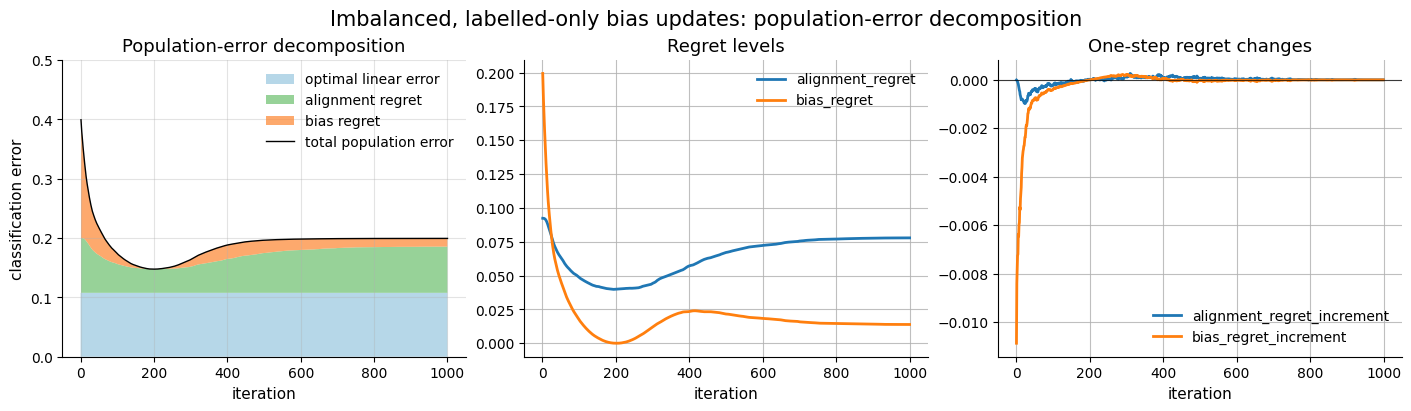

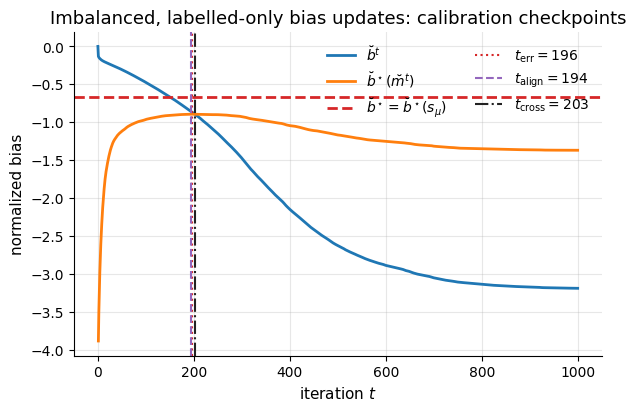

minimum population error:        t_err   = 196
maximum normalized alignment:    t_align = 194
closest conditional calibration: t_cross = 203
absolute calibration gap:                  0.00220744
sign-changing crossing observed:           True
first sign change:                         t=202 to t=203


In [33]:
imbalanced_labelled_bias = analyze_bias_experiment(
    name="Imbalanced, labelled-only bias updates",
    label_prior=IMBALANCED_PRIOR,
    eta=LABELLED_BIAS_ETA,
    pseudo_label_param=SELF_TRAINING_PI,
    bias_pseudo_label_param=LABELLED_ONLY_BIAS_WEIGHT,
    initial_bias=0.0
)

Imbalanced, labelled-only bias updates: p=0.2, n=8000, d=1000, labelled=72, unlabelled=7928, delta_finite=8.000, s_mu=1.0291


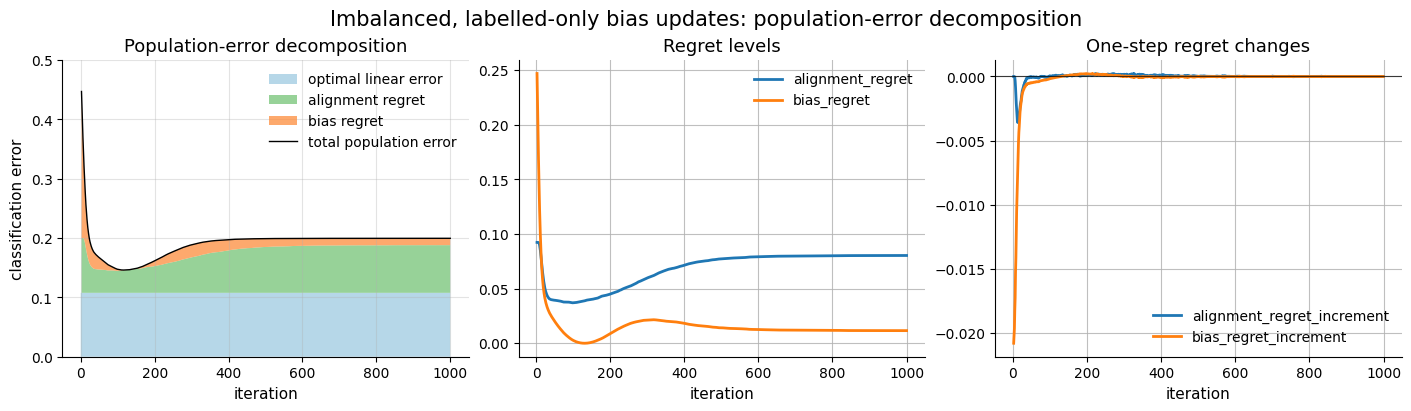

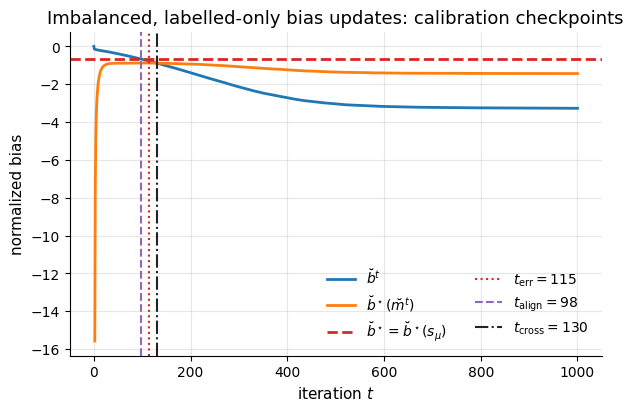

minimum population error:        t_err   = 115
maximum normalized alignment:    t_align = 98
closest conditional calibration: t_cross = 130
absolute calibration gap:                  0.00196323
sign-changing crossing observed:           True
first sign change:                         t=130 to t=131


In [40]:
imbalanced_labelled_bias = analyze_bias_experiment(
    name="Imbalanced, labelled-only bias updates",
    label_prior=IMBALANCED_PRIOR,
    eta=LABELLED_BIAS_ETA,
    pseudo_label_param=SELF_TRAINING_PI,
    bias_pseudo_label_param=LABELLED_ONLY_BIAS_WEIGHT,
    initial_bias=0.0,
    kappa_neg=-logit(0.75),
    kappa_pos=logit(0.95)
)

Imbalanced, labelled-only bias updates: p=0.2, n=8000, d=1000, labelled=72, unlabelled=7928, delta_finite=8.000, s_mu=1.0291


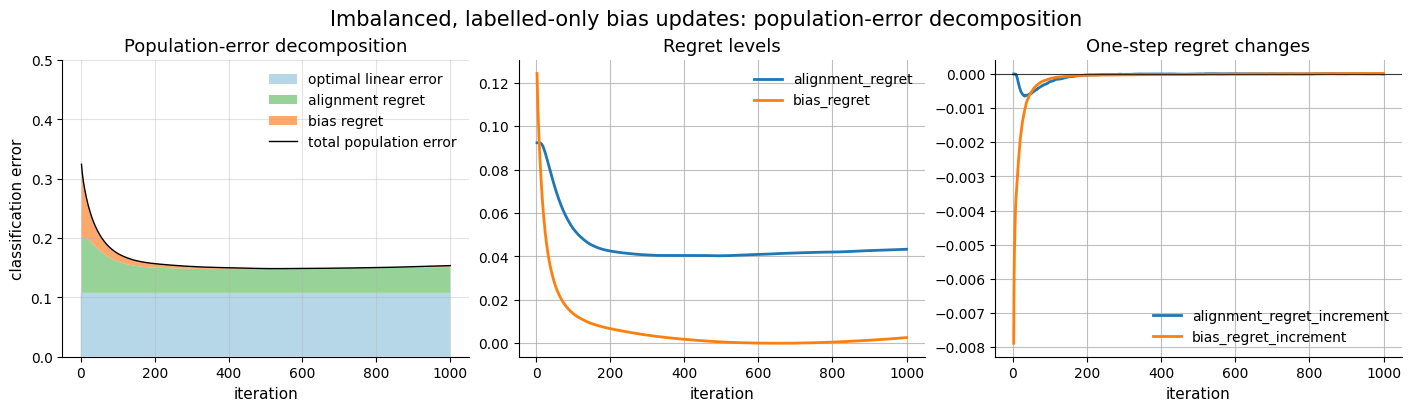

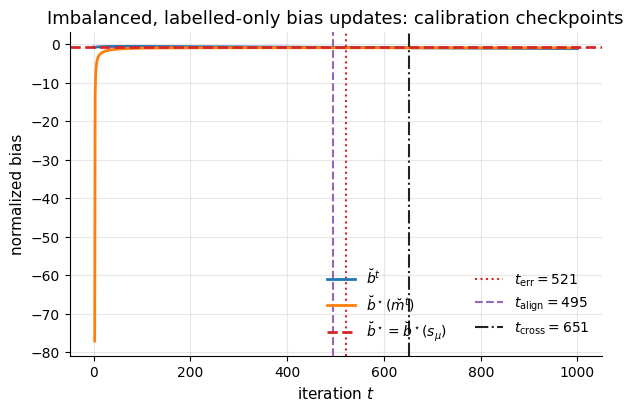

minimum population error:        t_err   = 521
maximum normalized alignment:    t_align = 495
closest conditional calibration: t_cross = 651
absolute calibration gap:                  5.09664e-05
sign-changing crossing observed:           True
first sign change:                         t=651 to t=652


In [42]:
imbalanced_labelled_bias = analyze_bias_experiment(
    name="Imbalanced, labelled-only bias updates",
    label_prior=IMBALANCED_PRIOR,
    eta=0.1,
    pseudo_label_param=SELF_TRAINING_PI,
    bias_pseudo_label_param=LABELLED_ONLY_BIAS_WEIGHT,
    initial_bias=global_optimal_bias,
    kappa_neg=-logit(0.75),
    kappa_pos=logit(0.95)
)

### Imbalanced classes: self-training with fully coupled bias updates

Here $p=0.2$, $\eta=0.1$, and $\pi_b=\pi=2$. Pseudo-labelled observations update both the weight vector and the bias.

Imbalanced, fully coupled bias updates: p=0.2, n=8000, d=1000, labelled=72, unlabelled=7928, delta_finite=8.000, s_mu=1.0291


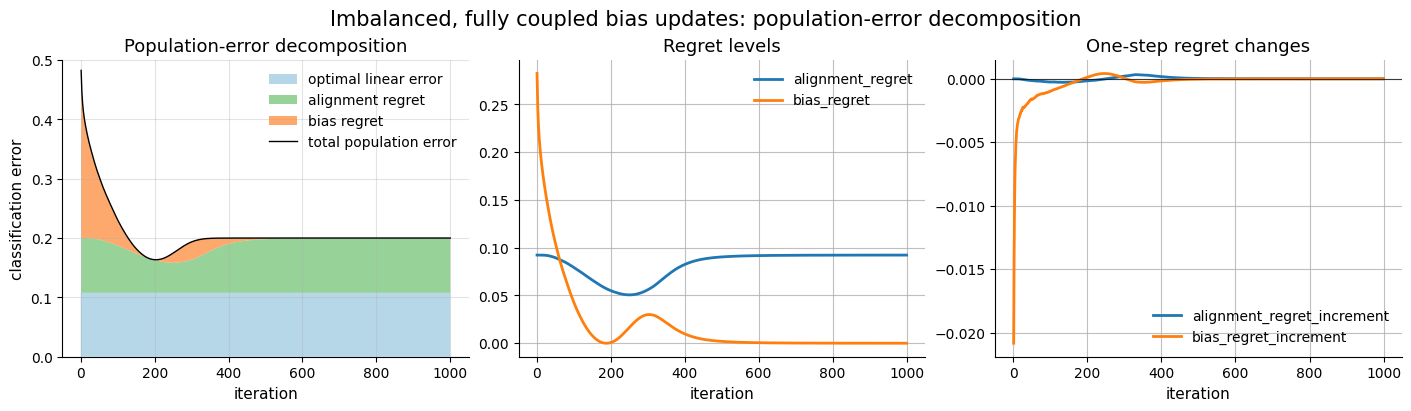

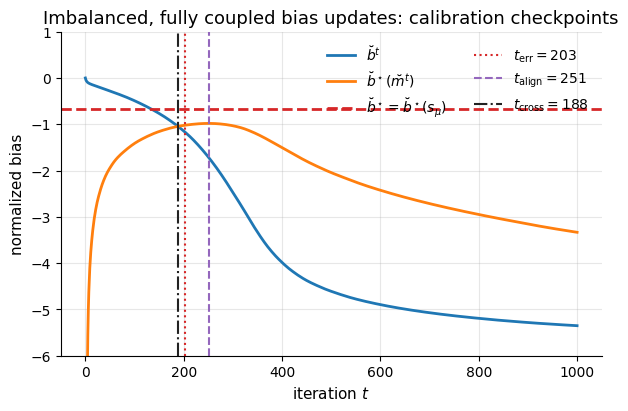

minimum population error:        t_err   = 203
maximum normalized alignment:    t_align = 251
closest conditional calibration: t_cross = 188
absolute calibration gap:                  0.00357372
sign-changing crossing observed:           True
first sign change:                         t=188 to t=189


In [23]:
imbalanced_full_bias = analyze_bias_experiment(
    name="Imbalanced, fully coupled bias updates",
    label_prior=IMBALANCED_PRIOR,
    eta=FULL_BIAS_ETA,
    pseudo_label_param=SELF_TRAINING_PI,
    bias_pseudo_label_param=FULL_BIAS_WEIGHT,
    bias_ylim=(-6.0, 1.0),
    initial_bias=0.0
)

### Imbalanced classes: self-training with fixed Bayes optimal bias

Here $p=0.2$, $\eta=0.1$, and $\pi_b=\pi=2$. Pseudo-labelled observations update only the weight vector.

Imbalanced, fully coupled bias updates: p=0.2, n=8000, d=1000, labelled=72, unlabelled=7928, delta_finite=8.000, s_mu=1.0291


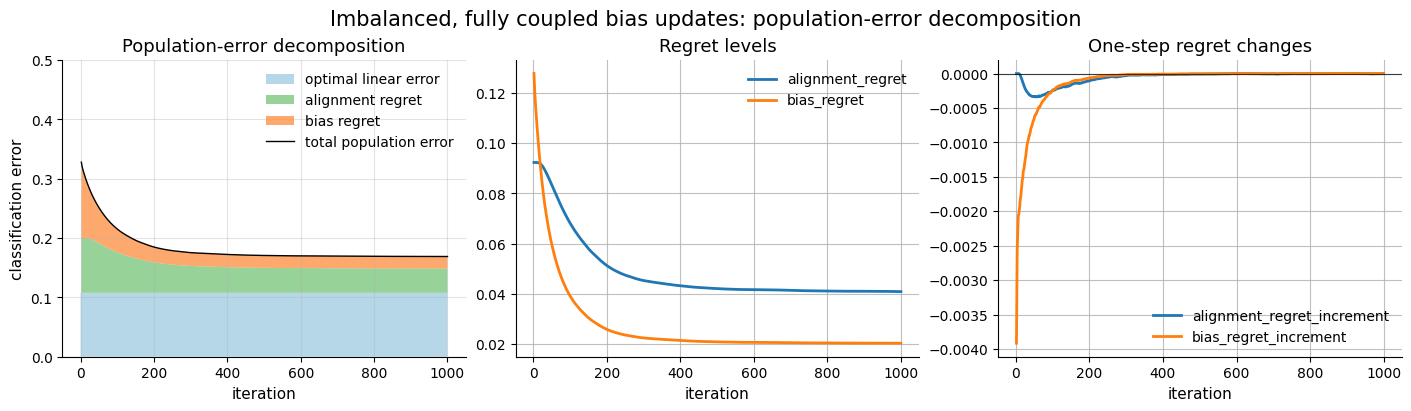

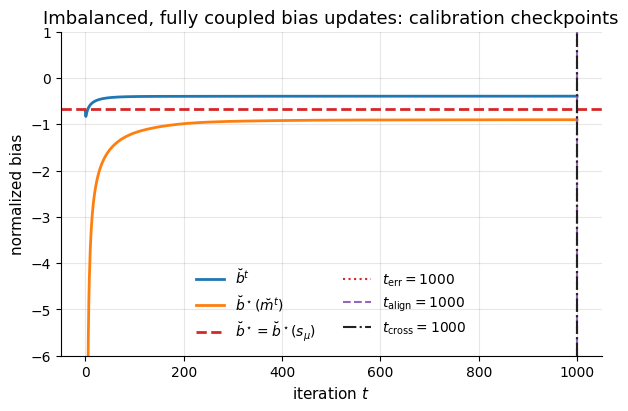

minimum population error:        t_err   = 1000
maximum normalized alignment:    t_align = 1000
closest conditional calibration: t_cross = 1000
absolute calibration gap:                  0.508547
sign-changing crossing observed:           False


In [18]:
imbalanced_fixed_bias = analyze_bias_experiment(
    name="Imbalanced, fully coupled bias updates",
    label_prior=IMBALANCED_PRIOR,
    eta=FULL_BIAS_ETA,
    pseudo_label_param=SELF_TRAINING_PI,
    bias_pseudo_label_param=FULL_BIAS_WEIGHT,
    bias_ylim=(-6.0, 1.0),
    include_bias=False,
    initial_bias=global_optimal_bias
)

### Imbalanced classes: supervised baseline

Here $p=0.2$, $\eta=1$, and $\pi=0$. Pseudo-labelled observations contribute to neither the weight-vector update nor the bias update.

Imbalanced, supervised baseline: p=0.2, n=8000, d=1000, labelled=72, unlabelled=7928, delta_finite=8.000, s_mu=1.0291


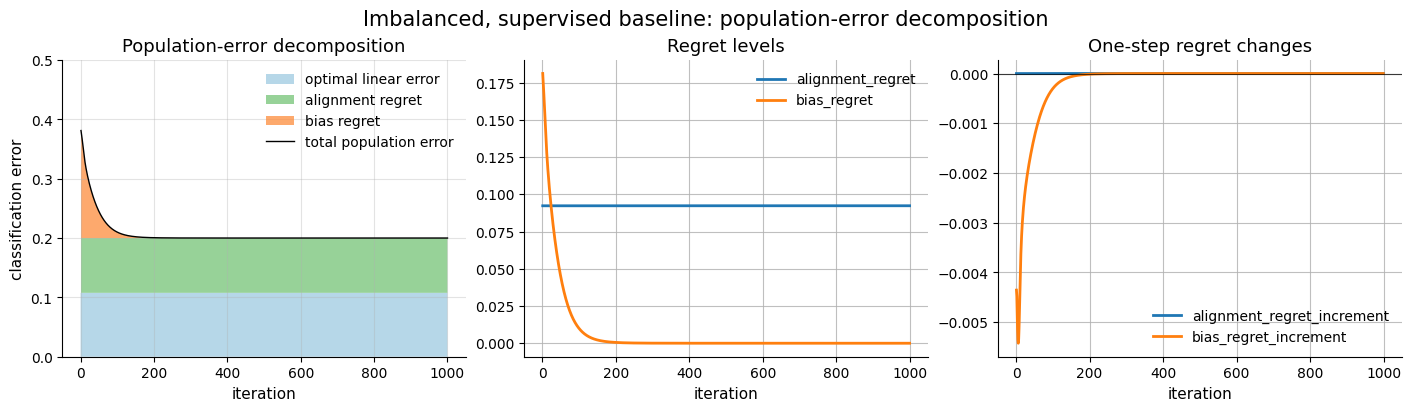

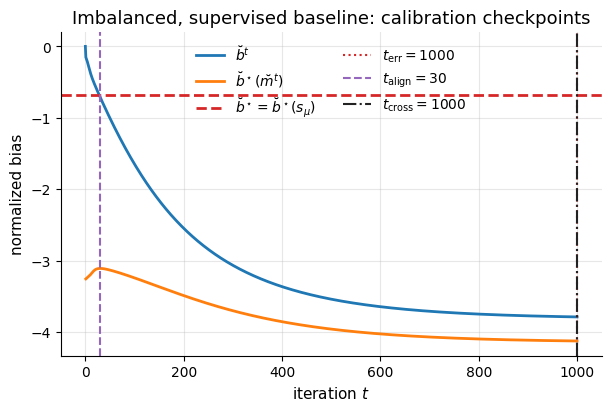

minimum population error:        t_err   = 1000
maximum normalized alignment:    t_align = 30
closest conditional calibration: t_cross = 1000
absolute calibration gap:                  0.336803
sign-changing crossing observed:           False


In [12]:
imbalanced_supervised = analyze_bias_experiment(
    name="Imbalanced, supervised baseline",
    label_prior=IMBALANCED_PRIOR,
    eta=SUPERVISED_ETA,
    pseudo_label_param=SUPERVISED_PI,
    bias_pseudo_label_param=FULL_BIAS_WEIGHT,
)

### Balanced classes: self-training with labelled-only bias updates

Here $p=0.5$, $\eta=1$, $\pi=2$, and $\pi_b=0$. The conditionally optimal and globally optimal normalized biases are both zero.

Balanced, labelled-only bias updates: p=0.5, n=8000, d=1000, labelled=77, unlabelled=7923, delta_finite=8.000, s_mu=1.0291


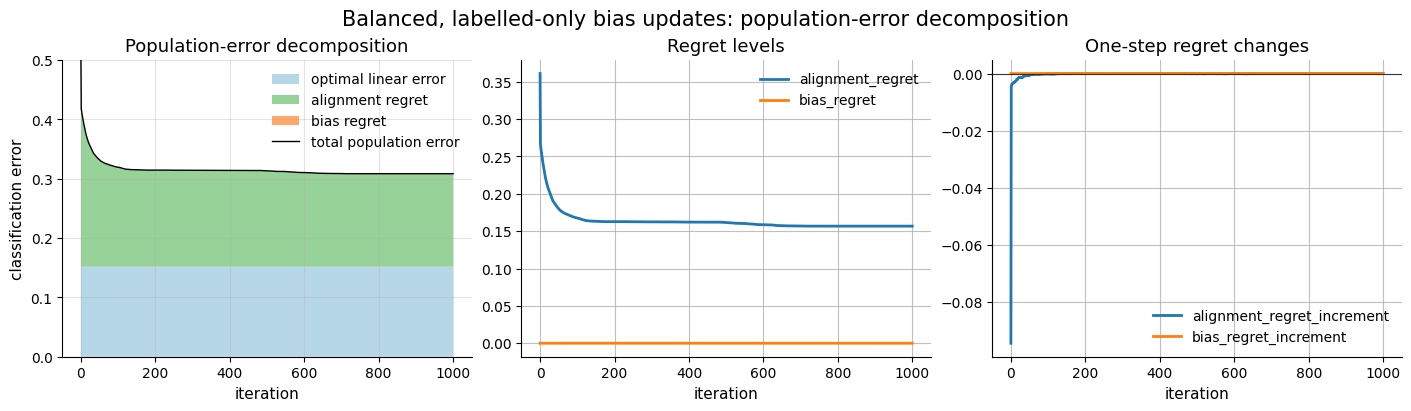

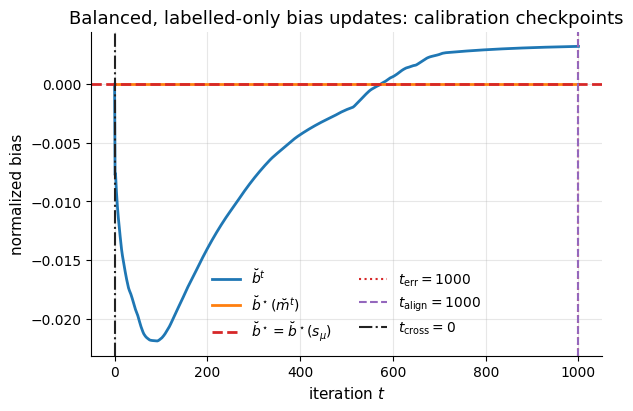

minimum population error:        t_err   = 1000
maximum normalized alignment:    t_align = 1000
closest conditional calibration: t_cross = 0
absolute calibration gap:                  0
sign-changing crossing observed:           True
first sign change:                         t=572 to t=573


In [13]:
balanced_labelled_bias = analyze_bias_experiment(
    name="Balanced, labelled-only bias updates",
    label_prior=BALANCED_PRIOR,
    eta=LABELLED_BIAS_ETA,
    pseudo_label_param=SELF_TRAINING_PI,
    bias_pseudo_label_param=LABELLED_ONLY_BIAS_WEIGHT,
)

### Balanced classes: self-training with fully coupled bias updates

Here $p=0.5$, $\eta=0.1$, and $\pi_b=\pi=2$. The bias receives both labelled and pseudo-labelled contributions.

Balanced, fully coupled bias updates: p=0.5, n=8000, d=1000, labelled=77, unlabelled=7923, delta_finite=8.000, s_mu=1.0291


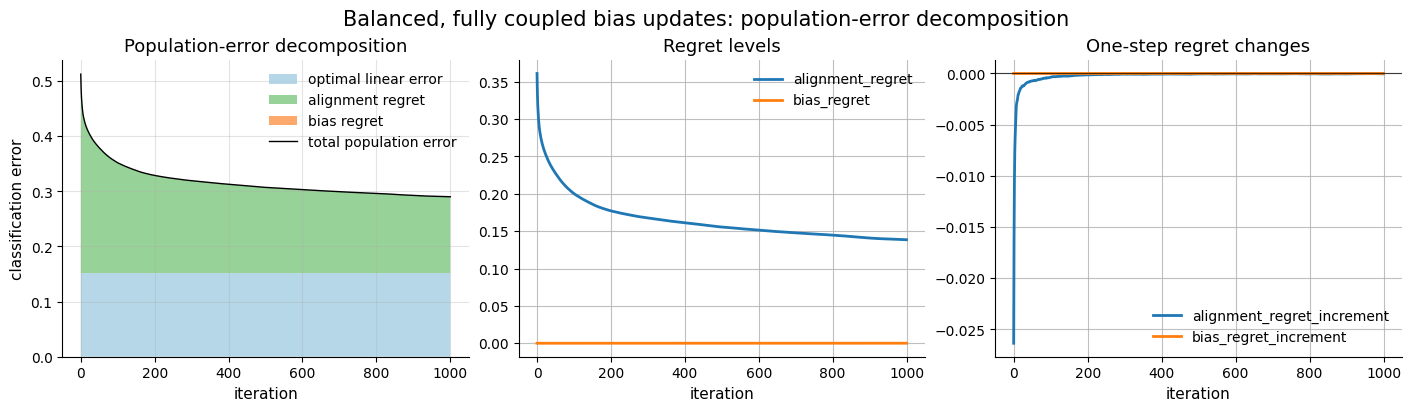

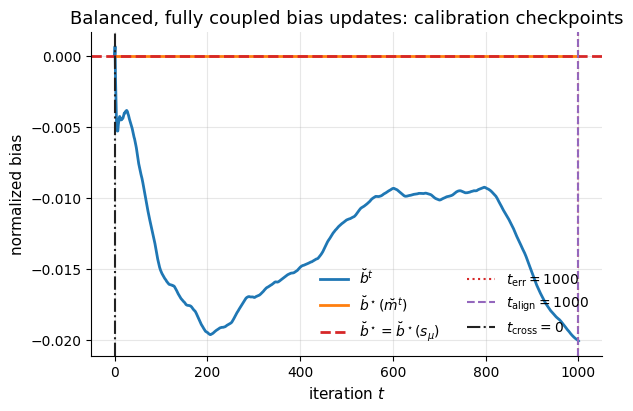

minimum population error:        t_err   = 1000
maximum normalized alignment:    t_align = 1000
closest conditional calibration: t_cross = 0
absolute calibration gap:                  0
sign-changing crossing observed:           True
first sign change:                         t=1 to t=2


In [12]:
balanced_full_bias = analyze_bias_experiment(
    name="Balanced, fully coupled bias updates",
    label_prior=BALANCED_PRIOR,
    eta=FULL_BIAS_ETA,
    pseudo_label_param=SELF_TRAINING_PI,
    bias_pseudo_label_param=FULL_BIAS_WEIGHT,
)

### Balanced classes: supervised baseline

Here $p=0.5$, $\eta=1$, and $\pi=0$. Only labelled observations contribute to the parameter updates.

Balanced, supervised baseline: p=0.5, n=8000, d=1000, labelled=77, unlabelled=7923, delta_finite=8.000, s_mu=1.0291


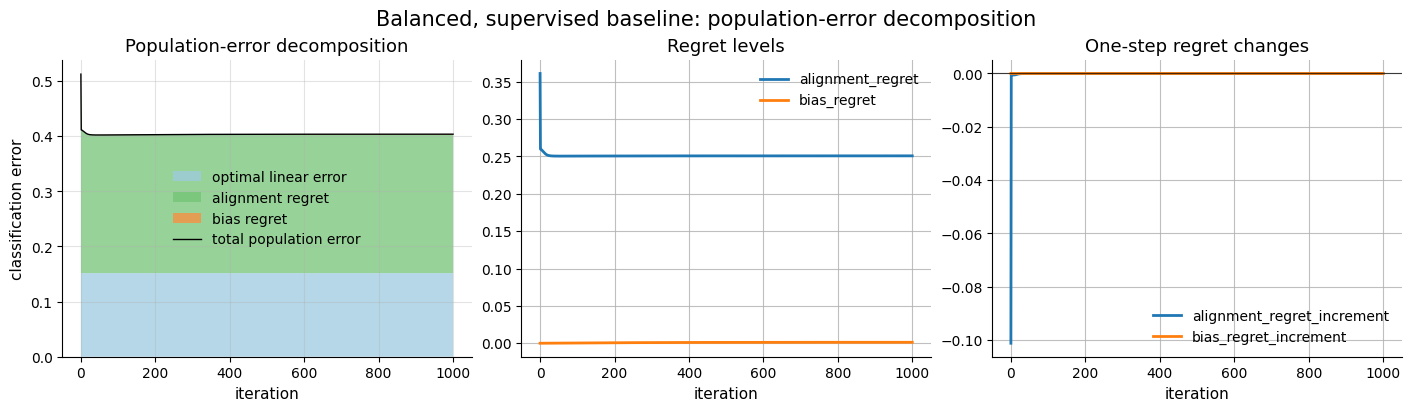

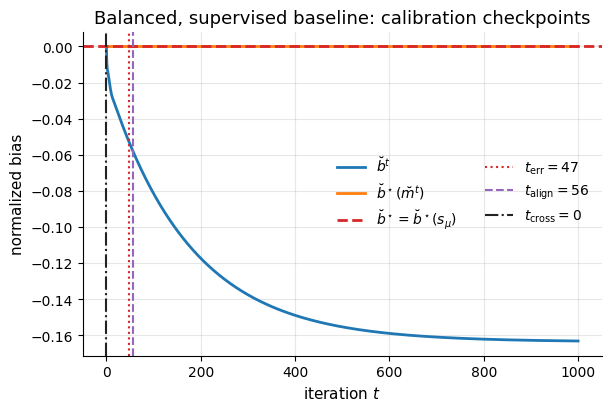

minimum population error:        t_err   = 47
maximum normalized alignment:    t_align = 56
closest conditional calibration: t_cross = 0
absolute calibration gap:                  0
sign-changing crossing observed:           False


In [13]:
balanced_supervised = analyze_bias_experiment(
    name="Balanced, supervised baseline",
    label_prior=BALANCED_PRIOR,
    eta=SUPERVISED_ETA,
    pseudo_label_param=SUPERVISED_PI,
    bias_pseudo_label_param=FULL_BIAS_WEIGHT,
)

## Empirical conclusions

The six experiments place the two class priors and three update conventions on equal footing. In every panel, the same decomposition separates the error associated with suboptimal alignment from the additional error associated with conditional bias miscalibration. For balanced classes, the conditional and global optimal biases are identically zero; for imbalanced classes, the conditional optimum varies with normalized alignment.

Temporal proximity among $t_{\mathrm{err}}$, $t_{\mathrm{align}}$, and $t_{\mathrm{cross}}$ documents synchronization along a trajectory but does not establish that bias overshoot causes alignment deterioration. A causal interpretation requires analysis of the bias-to-alignment feedback in the effective dynamics.